# Precios de gafas graduadas. 1. Adquisición de datos y análisis de surtido

Juan Antonio Muñoz Moreno · agosto 2026

---

## La pregunta

Las dos grandes cadenas de óptica que venden online en España pertenecen a fabricantes de gafas rivales entre sí:

| Cadena | Propietario | Fuente (verificada 1 ago 2026) |
|---|---|---|
| Óptica 2000 | Grandvisión Spain → EssilorLuxottica | Pie de página de optica2000.com + comunicado de EssilorLuxottica (adquisición de GrandVision cerrada el 1 jul 2021) |
| General Óptica | Grupo De Rigo | derigo.com: *"its chains General Optica, Mais Optica and Opmar Optik"* |

Eso permite plantear una pregunta que no es de producto sino de estructura de mercado:

> ¿Condiciona la propiedad del minorista lo que vende y a qué precio?

Es falsable y se contrasta contando referencias. Este notebook la responde.

## Lo que NO es este notebook

No es un modelo de precios ni pretende ayudar a una óptica a fijar tarifas. El precio de unas gafas graduadas está dominado por la lente, el laboratorio, el local y el tiempo del optometrista, no por la montura. Aquí se analiza cómo la concentración del sector se refleja en el surtido y en el precio de catálogo, y nada más.

---
## 1. Fuentes y cumplimiento

Los datos se capturan con dos scrapers propios (`src/scraping/`). Las condiciones de cada sitio se comprobaron antes de escribir una línea de código:

| | Óptica 2000 | General Óptica |
|---|---|---|
| Renderizado | servidor | JavaScript (requiere navegador) |
| Herramienta | `requests` + BeautifulSoup | Selenium |
| `Crawl-delay` en robots.txt | no declara → se usa 1 s | 30 s → se respeta |
| Tiempo de rastreo | ~20 min | ~15 h |
| Datos estructurados | etiquetas de texto | JSON-LD completo |

Decisiones de cumplimiento:

- Las URLs se enumeran desde el `sitemap.xml`, que es la vía que cada sitio publica para ser rastreado, no desde listados de categoría.
- El `User-Agent` identifica el proyecto y un correo de contacto en vez de hacerse pasar por un navegador.
- El `Crawl-delay: 30` de General Óptica se respeta íntegro. Son 15 horas de rastreo y ese es el precio de hacerlo bien.
- Ninguna URL rastreada coincide con las rutas prohibidas en los respectivos `robots.txt`.

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ / "src" / "scraping"))
from marcas import asignar_grupo, sin_cruzar   # noqa: E402

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
pd.set_option("display.width", 200)

# El EAN se lee como TEXTO a propósito: son 13 dígitos y si pandas lo infiere
# como número puede perder precisión y romper el cruce entre tiendas.
o2 = pd.read_csv(RAIZ / "data/raw/optica2000_graduadas.csv", dtype={"ean": str})
go = pd.read_csv(RAIZ / "data/raw/generaloptica_graduadas.csv", dtype={"ean": str})
go["ean"] = go["ean"].str.split(".").str[0]      # limpia notación científica residual

# Las dos tiendas codifican la disponibilidad con nombre y formato distintos.
# Se unifica en una sola columna booleana ANTES de cualquier análisis.
o2["en_stock"] = o2["disponible"].astype(bool)
go["en_stock"] = (go["disponibilidad"].str.split("/").str[-1]
                  .isin(["InStock", "InStoreOnly", "OnlineOnly"]))

print(f"Óptica 2000    : {len(o2):>5} productos · {o2['marca'].nunique():>3} marcas")
print(f"General Óptica : {len(go):>5} productos · {go['marca'].nunique():>3} marcas")
print(f"TOTAL          : {len(o2)+len(go):>5} productos")
print(f"\nCaptura: {min(o2['ts_captura'].min(), go['ts_captura'].min())[:10]} "
      f"a {max(o2['ts_captura'].max(), go['ts_captura'].max())[:10]}")

Óptica 2000    :  1296 productos ·  35 marcas
General Óptica :  4825 productos ·  90 marcas
TOTAL          :  6121 productos

Captura: 2026-08-02 a 2026-08-04


---
## 2. Calidad del dato

Antes de interpretar nada hay que saber qué falta y qué no cuadra. Cada fila lleva su propio `ts_captura` porque un rastreo de 15 horas puede cruzarse con un cambio de campaña promocional, y sin marca de tiempo no habría forma de detectarlo.

In [2]:
def nulos(df, nombre):
    n = (100 * df.isna().mean()).round(1)
    n = n[n > 0].sort_values(ascending=False)
    print(f"--- {nombre}: columnas con nulos (%) ---")
    print(n.to_string() if len(n) else "  ninguna")
    print()

nulos(o2, "Óptica 2000")
nulos(go, "General Óptica")

--- Óptica 2000: columnas con nulos (%) ---
mpn                 100.0
descuento_pct        82.2
precio_anterior      82.2
tipo_montura          6.6
forma                 3.1
ancho_montura         1.9
largo_varilla         1.8
color                 0.2
genero                0.1
material_montura      0.1
ancho_lente           0.1
ancho_puente          0.1
precio_actual         0.1
pvp                   0.1

--- General Óptica: columnas con nulos (%) ---
ean                0.7
precio_anterior    0.1
ancho_lente        0.1
ancho_puente       0.1
descuento_pct      0.1



`mpn` está vacío al 100 % en Óptica 2000: esa tienda no publica JSON-LD, así que no hay código de fabricante. Para cruzar con otros catálogos hay que usar la columna `modelo` (por ejemplo `AX3077 8001`), que lleva código de modelo y de color.

`precio_anterior` y `descuento_pct` están vacíos cuando el producto no está rebajado. No es un fallo: es la ausencia de oferta.

In [3]:
# Comprobaciones de coherencia interna. Si alguna falla, hay un fallo de parseo.
def coherencia(df, nombre):
    d = df[df["precio_actual"].notna()]
    pruebas = {
        "pvp >= precio_actual siempre": bool((d["pvp"] >= d["precio_actual"]).all()),
        "pvp == precio_anterior cuando hay oferta":
            bool((d.loc[d["en_oferta"], "pvp"] == d.loc[d["en_oferta"], "precio_anterior"]).all()),
        "pvp == precio_actual cuando NO hay oferta":
            bool((d.loc[~d["en_oferta"], "pvp"] == d.loc[~d["en_oferta"], "precio_actual"]).all()),
        "precio es de montura sola":
            f"{int(d['precio_solo_montura'].sum())}/{len(d)}",
        "descuentos observados": sorted(d.loc[d['en_oferta'], 'descuento_pct'].dropna().unique())[:8],
    }
    print(f"--- {nombre} ---")
    for k, v in pruebas.items():
        print(f"  {k:44} {v}")
    print()

coherencia(o2, "Óptica 2000")
coherencia(go, "General Óptica")

--- Óptica 2000 ---
  pvp >= precio_actual siempre                 True
  pvp == precio_anterior cuando hay oferta     True
  pvp == precio_actual cuando NO hay oferta    True
  precio es de montura sola                    1295/1295
  descuentos observados                        [np.float64(20.0), np.float64(30.0), np.float64(50.0)]

--- General Óptica ---
  pvp >= precio_actual siempre                 True
  pvp == precio_anterior cuando hay oferta     True
  pvp == precio_actual cuando NO hay oferta    True
  precio es de montura sola                    4824/4825
  descuentos observados                        [np.float64(11.54), np.float64(19.23), np.float64(20.0), np.float64(25.0), np.float64(25.01), np.float64(25.81), np.float64(40.0), np.float64(50.0)]



Que el precio sea de la montura sola no es un detalle menor. Las cadenas de óptica venden habitualmente packs de montura + lentes, y un precio de pack no es comparable con el de una montura suelta. Las dos webs lo declaran de forma explícita en la ficha ("El precio indicado se corresponde solo a la montura", "Precio solo montura") y el scraper lo captura como comprobación.

---
## 3. El target: por qué PVP y no el precio del día

Aquí aparece el primer hallazgo, y condiciona todo lo demás.

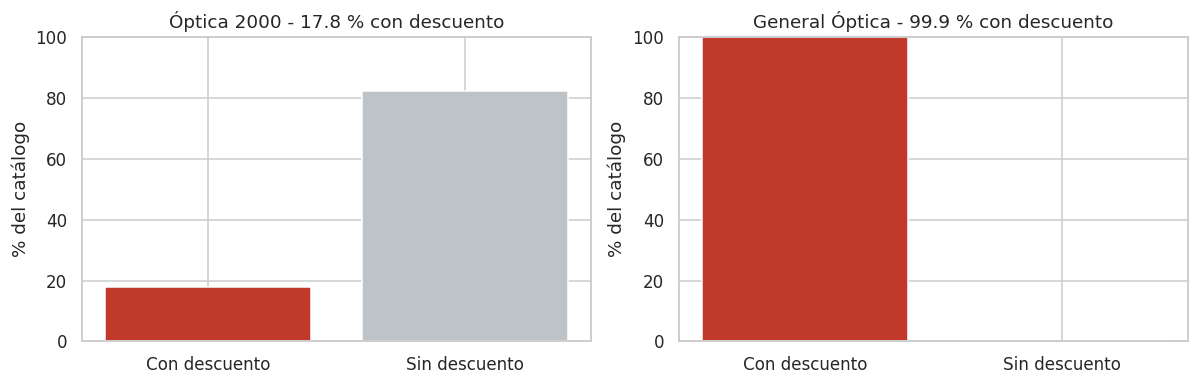

Descuentos aplicados en General Óptica:
descuento_pct
25.0    2365
60.0     933
50.0     690
20.0     360
40.0     288


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
for i, (df, nom) in enumerate([(o2, "Óptica 2000"), (go, "General Óptica")]):
    pct = 100 * df["en_oferta"].mean()
    ax[i].bar(["Con descuento", "Sin descuento"], [pct, 100 - pct],
              color=["#c0392b", "#bdc3c7"])
    ax[i].set_title(f"{nom} - {pct:.1f} % con descuento")
    ax[i].set_ylim(0, 100); ax[i].set_ylabel("% del catálogo")
plt.tight_layout(); plt.show()

print("Descuentos aplicados en General Óptica:")
print(go.loc[go["en_oferta"], "descuento_pct"].value_counts().head().to_string())

General Óptica no hace rebajas por producto: aplica una campaña a catálogo completo. Prácticamente todo su catálogo está descontado el mismo porcentaje el mismo día.

Consecuencia directa para el modelado: si se tomara `precio_actual` como variable objetivo, se estaría modelando la campaña de esa semana, no una propiedad del producto. Y `en_oferta` sería una constante, es decir, una variable inútil.

Por eso el target es el PVP (precio de catálogo), que los scrapers calculan así:

```python
pvp = precio_anterior if en_oferta else precio_actual
```

Cuando hay descuento, el PVP es el precio tachado; cuando no lo hay, el precio a secas ya es el de catálogo. El resultado es estable aunque la campaña cambie a mitad del rastreo.

Contexto legal que respalda usar el precio tachado: el artículo 20.1 de la Ley de Ordenación del Comercio Minorista, redactado por el Real Decreto-ley 24/2021 y en vigor desde el 28 de mayo de 2022, obliga a que el "precio anterior" anunciado sea el más bajo aplicado en los 30 días previos. No es una cifra inventada: es un precio realmente cobrado hace poco.

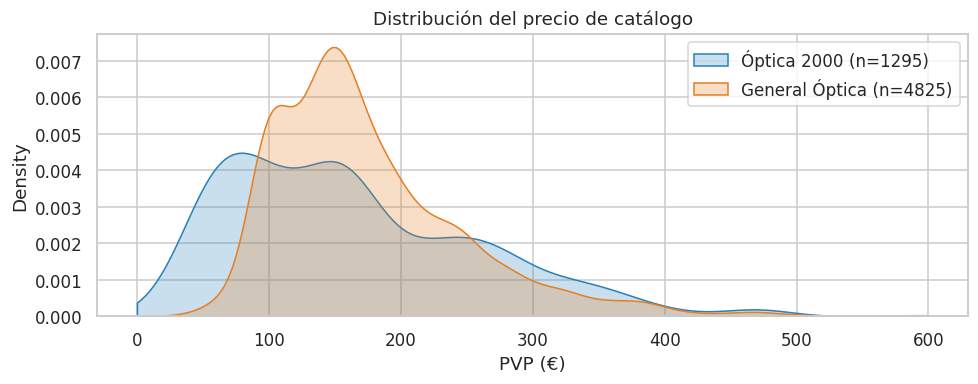

       Óptica 2000  General Óptica
count      1295.00         4825.00
mean        169.25          176.52
std         110.84           76.45
min          21.00           19.95
25%          85.50          125.00
50%         150.00          159.00
75%         230.00          210.00
max         770.00          846.50


In [5]:
fig, ax = plt.subplots(figsize=(9, 3.6))
for df, nom, c in [(o2, "Óptica 2000", "#2980b9"), (go, "General Óptica", "#e67e22")]:
    sns.kdeplot(df["pvp"].dropna(), label=f"{nom} (n={df['pvp'].notna().sum()})",
                ax=ax, fill=True, alpha=.25, color=c, clip=(0, 600))
ax.set_xlabel("PVP (€)"); ax.set_title("Distribución del precio de catálogo"); ax.legend()
plt.tight_layout(); plt.show()

print(pd.DataFrame({
    "Óptica 2000": o2["pvp"].describe(),
    "General Óptica": go["pvp"].describe(),
}).round(2).to_string())

---
## 4. La variable central: a qué grupo pertenece cada marca

En óptica, la variable estructural que manda no es el país de origen de la marca, porque casi todas las monturas salen de las mismas fábricas, sino qué grupo posee o licencia la marca. Esa información está publicada en las webs corporativas de cada grupo, así que es citable.

La tabla `marcas_grupo.csv` recoge 175 marcas con una fuente y una fecha por asignación:

| Grupo | Fuente primaria |
|---|---|
| EssilorLuxottica | `essilorluxottica.com/en/brands/eyewear/` |
| De Rigo | `derigo.com/en/our-brands/` + `/en/brand-partner/` |
| Safilo | `safilogroup.com/it/prodotto/marchi` |
| Marcolin | `marcolin.com/it/brand/` |
| Kering Eyewear | `keringeyewear.com/en/our-brands` |
| Marchon | `marchon.com/brands` |
| Marchon | `marchon.com/brands` |
| Mondottica | `mondottica.com/brands/hackett/` |
| Thélios (LVMH) | Comunicado de Thélios + WWD (Bvlgari, licencia efectiva ene-2024) |
| Silhouette · Eschenbach · Julbo · Vuillet Vega | Webs corporativas respectivas (agrupadas como *Independiente*) |

Por qué no se construyó de memoria. Una versión previa de este proyecto usaba una tabla de gamas de marca generada con un modelo de lenguaje. Al contrastarla con los precios reales observados, la correlación era de 0,642 y el error mediano del 66,8 % (Max Mara estimada en 260 € frente a 92,90 € reales sobre 43 productos). Se eliminó por completo.

Al construir la tabla desde fuentes primarias aparecieron cuatro asignaciones que se habrían hecho mal de memoria: Swarovski y Moncler son licencias de EssilorLuxottica y no de Marcolin; Rodenstock es socio de marca de De Rigo; y Bvlgari pasó de EssilorLuxottica a Thélios en enero de 2024.

In [6]:
o2["grupo"] = asignar_grupo(o2["marca"])
go["grupo"] = asignar_grupo(go["marca"])

for df, nom in [(o2, "Óptica 2000"), (go, "General Óptica")]:
    c = df["grupo"].notna().mean()
    print(f"{nom:16} {df['grupo'].notna().sum():>5}/{len(df):<5} con grupo asignado ({100*c:.1f} %)")

falta = sin_cruzar(go["marca"])
print(f"\nMarcas sin clasificar en General Óptica: {len(falta)} "
      f"({falta['n'].sum()} fichas, {100*falta['n'].sum()/len(go):.1f} %)")
print(falta.head(8).to_string(index=False))

Óptica 2000       1296/1296  con grupo asignado (100.0 %)
General Óptica    4809/4825  con grupo asignado (99.7 %)

Marcas sin clasificar en General Óptica: 6 (16 fichas, 0.3 %)
    marca     clave  n
Ver Sport ver-sport  5
 The Wave  the-wave  4
       XL        xl  4
Day&Night day-night  1
  Goppies   goppies  1
   Lanvin    lanvin  1


Las marcas que no cruzan quedan como nulo a propósito. Es preferible un hueco visible a una categoría "otros" que esconda un fallo de normalización.

---
## 5. El censo de surtido

Ahora la pregunta del principio, contando referencias.

In [7]:
tabla = pd.DataFrame({
    "Óptica 2000": o2["grupo"].value_counts(),
    "General Óptica": go["grupo"].value_counts(),
}).fillna(0).astype(int)
tabla["O2 %"] = (100 * tabla["Óptica 2000"] / len(o2)).round(1)
tabla["GO %"] = (100 * tabla["General Óptica"] / len(go)).round(1)
tabla = tabla.sort_values("Óptica 2000", ascending=False)
tabla[["Óptica 2000", "O2 %", "General Óptica", "GO %"]]

,Óptica 2000,O2 %,General Óptica,GO %
grupo,,,,
EssilorLuxottica,921,71.1,1761,36.5
GrandVision (retailer),248,19.1,0,0.0
Kering Eyewear,43,3.3,228,4.7
Independiente,42,3.2,501,10.4
Marcolin,28,2.2,178,3.7
De Rigo,8,0.6,1333,27.6
Safilo,6,0.5,404,8.4
GO Eyewear Group,0,0.0,28,0.6
Federópticos,0,0.0,29,0.6


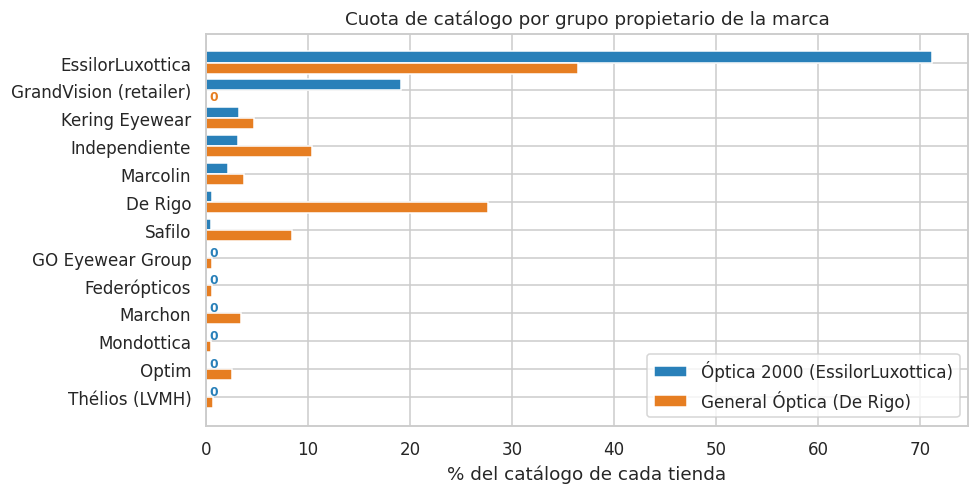

In [8]:
orden = tabla.index.tolist()
y = np.arange(len(orden)); h = 0.4
fig, ax = plt.subplots(figsize=(9, 4.6))
ax.barh(y - h/2, tabla["O2 %"], h, label="Óptica 2000 (EssilorLuxottica)", color="#2980b9")
ax.barh(y + h/2, tabla["GO %"], h, label="General Óptica (De Rigo)", color="#e67e22")
ax.set_yticks(y); ax.set_yticklabels(orden); ax.invert_yaxis()
ax.set_xlabel("% del catálogo de cada tienda")
ax.set_title("Cuota de catálogo por grupo propietario de la marca")
ax.legend(loc="lower right")
for i, (a, b) in enumerate(zip(tabla["O2 %"], tabla["GO %"])):
    if a == 0: ax.text(0.4, i - h/2, "0", va="center", fontsize=8, color="#2980b9", weight="bold")
    if b == 0: ax.text(0.4, i + h/2, "0", va="center", fontsize=8, color="#e67e22", weight="bold")
plt.tight_layout(); plt.show()

In [9]:
RIVALES_DE_O2 = ["De Rigo", "Safilo", "Marcolin", "Kering Eyewear",
                 "Marchon", "Thélios (LVMH)", "Optim", "GO Eyewear Group"]

propio_o2 = tabla.loc[["EssilorLuxottica", "GrandVision (retailer)"], "Óptica 2000"].sum()
rivales_o2 = tabla.reindex(RIVALES_DE_O2)["Óptica 2000"].fillna(0).sum()
propio_go = tabla.loc["De Rigo", "General Óptica"]
rival_go = tabla.loc["EssilorLuxottica", "General Óptica"]

print("ÓPTICA 2000  (propiedad de EssilorLuxottica)")
print(f"   marcas de su grupo + marca blanca propia : {propio_o2:>5}  ({100*propio_o2/len(o2):>5.1f} %)")
print(f"   TODOS los fabricantes rivales juntos     : {int(rivales_o2):>5}  ({100*rivales_o2/len(o2):>5.1f} %)")
print()
print("GENERAL ÓPTICA  (propiedad de De Rigo)")
print(f"   marcas de su propio grupo                : {propio_go:>5}  ({100*propio_go/len(go):>5.1f} %)")
print(f"   marcas de EssilorLuxottica (su rival)    : {rival_go:>5}  ({100*rival_go/len(go):>5.1f} %)")
print()
print("Grupos con CERO presencia en Óptica 2000:")
for g_ in RIVALES_DE_O2:
    if g_ in tabla.index and tabla.loc[g_, "Óptica 2000"] == 0:
        print(f"   {g_:20} - {tabla.loc[g_, 'General Óptica']} referencias en General Óptica")

ÓPTICA 2000  (propiedad de EssilorLuxottica)
   marcas de su grupo + marca blanca propia :  1169  ( 90.2 %)
   TODOS los fabricantes rivales juntos     :    85  (  6.6 %)

GENERAL ÓPTICA  (propiedad de De Rigo)
   marcas de su propio grupo                :  1333  ( 27.6 %)
   marcas de EssilorLuxottica (su rival)    :  1761  ( 36.5 %)

Grupos con CERO presencia en Óptica 2000:
   Marchon              - 167 referencias en General Óptica
   Thélios (LVMH)       - 32 referencias en General Óptica
   Optim                - 124 referencias en General Óptica
   GO Eyewear Group     - 28 referencias en General Óptica


### El hallazgo

La hipótesis de partida era simétrica: *cada cadena favorece las marcas de su dueño*. Los datos la desmienten. La exclusión va en una sola dirección.

- El 90 % del catálogo de Óptica 2000 es de EssilorLuxottica o de la marca blanca de su propia cadena. Todos los fabricantes rivales juntos no llegan al 7 %.
- General Óptica dedica a su competidor el 36,5 % del catálogo que lista, más que a su propio grupo (27,6 %). Contando solo lo que tiene en stock la relación se invierte (24,5 % frente a 38,7 %): lista marca ajena y almacena la propia.
- Cuatro grupos completos están en cero absoluto en Óptica 2000. Entre ellos Marchon, que licencia Nike, Lacoste, Calvin Klein y Salvatore Ferragamo: marcas masivas que cualquier óptica tiene.

Lectura. De Rigo no puede sostener una cadena de ópticas en España sin Ray-Ban; EssilorLuxottica sí puede sostener una sin Police. No es preferencia comercial: es poder de mercado medido como capacidad de excluir. Y explica por qué Óptica 2000 tiene 35 marcas frente a las 90 de General Óptica.

### ¿Catálogo listado o catálogo comprable?

El recuento anterior cuenta lo que cada cadena lista. Pero General Óptica publica precio de mucho producto que no tiene en stock, y eso cambia la lectura.

Las dos tiendas codifican la disponibilidad de forma distinta:

| | Campo | Valores |
|---|---|---|
| Óptica 2000 | `disponible` | booleano; casi siempre True porque el scraper descarta los no disponibles al rastrear |
| General Óptica | `disponibilidad` | `InStock`, `OutOfStock`, `InStoreOnly`, `Discontinued`, `OnlineOnly` |

Se unifican en `en_stock`. Un detalle que rompe la intuición: el descuento no depende del stock. El 100 % de los productos agotados está rebajado, igual que los disponibles. General Óptica aplica la campaña a la tarifa y no a las existencias, así que no es una liquidación sino una promoción de catálogo. Un motivo más para modelar el PVP y no el precio del día.

Y hay que decir de entrada que la comparación no es simétrica: en Óptica 2000 el filtrado ocurre al capturar, así que no se puede saber cuánto de su catálogo estaría agotado.

In [10]:
print("General Óptica - estado de stock:")
print(go["disponibilidad"].str.split("/").str[-1].value_counts().to_string())
print(f"\nEn stock: {go['en_stock'].sum()} de {len(go)} ({100*go['en_stock'].mean():.1f} %)")
print(f"Óptica 2000 en stock: {o2['en_stock'].sum()} de {len(o2)}")

# Comprobación que rompe una intuición: ¿descuentan solo lo que tienen?
print("\n--- ¿el descuento depende del stock? ---")
print(f"  % con descuento entre los AGOTADOS : {100*go[~go['en_stock']]['en_oferta'].mean():.1f} %")
print(f"  % con descuento entre los EN STOCK : {100*go[go['en_stock']]['en_oferta'].mean():.1f} %")
print("\n  Los únicos productos SIN descuento de toda la tienda:")
print(go.loc[~go["en_oferta"], ["marca", "pvp", "disponibilidad"]].to_string(index=False))

General Óptica - estado de stock:
disponibilidad
OutOfStock      3045
InStock         1767
InStoreOnly        8
Discontinued       4
OnlineOnly         1

En stock: 1776 de 4825 (36.8 %)
Óptica 2000 en stock: 1295 de 1296

--- ¿el descuento depende del stock? ---
  % con descuento entre los AGOTADOS : 100.0 %
  % con descuento entre los EN STOCK : 99.9 %

  Los únicos productos SIN descuento de toda la tienda:
         marca   pvp                 disponibilidad
   Boss Orange 109.0  http://schema.org/InStoreOnly
Emporio Armani 358.0 http://schema.org/Discontinued
  Mr.Wonderful 105.0  http://schema.org/InStoreOnly


GENERAL ÓPTICA · 4825 listados vs 1776 en stock

                  listado_n  stock_n  listado_%  stock_%  unidades_perdidas
grupo                                                                      
EssilorLuxottica       1761      436       36.5     24.5               1325
De Rigo                1333      688       27.6     38.7                645
Independiente           501      133       10.4      7.5                368
Safilo                  404      128        8.4      7.2                276
Kering Eyewear          228      129        4.7      7.3                 99
Marcolin                178       93        3.7      5.2                 85
Marchon                 167       88        3.5      5.0                 79
Optim                   124       46        2.6      2.6                 78
Thélios (LVMH)           32        0        0.7      0.0                 32
Federópticos             29       18        0.6      1.0                 11
GO Eyewear Group         28        0   

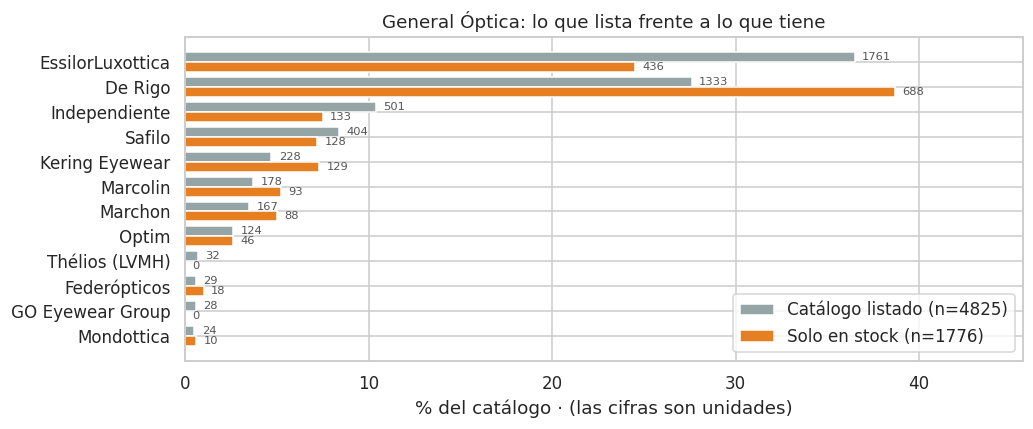

In [11]:
gs = go[go["en_stock"]]
comp = pd.DataFrame({
    "listado_n": go["grupo"].value_counts(),
    "stock_n": gs["grupo"].value_counts(),
}).fillna(0).astype(int)
comp["listado_%"] = (100 * comp["listado_n"] / len(go)).round(1)
comp["stock_%"] = (100 * comp["stock_n"] / len(gs)).round(1)
comp["unidades_perdidas"] = comp["listado_n"] - comp["stock_n"]
comp = comp.sort_values("listado_n", ascending=False)
print(f"GENERAL ÓPTICA · {len(go)} listados vs {len(gs)} en stock\n")
print(comp.to_string())

fig, ax = plt.subplots(figsize=(9.5, 4))
y = np.arange(len(comp)); h = .4
b1 = ax.barh(y - h/2, comp["listado_%"], h, label=f"Catálogo listado (n={len(go)})", color="#95a5a6")
b2 = ax.barh(y + h/2, comp["stock_%"], h, label=f"Solo en stock (n={len(gs)})", color="#e67e22")
# Las unidades absolutas van encima de cada barra: los dos porcentajes se
# calculan sobre TOTALES DISTINTOS, así que sin el recuento la gráfica se lee mal.
for b, col in [(b1, "listado_n"), (b2, "stock_n")]:
    for rect, n in zip(b, comp[col]):
        ax.text(rect.get_width() + .4, rect.get_y() + rect.get_height()/2,
                f"{n}", va="center", fontsize=7.5, color="#555")
ax.set_yticks(y); ax.set_yticklabels(comp.index); ax.invert_yaxis()
ax.set_xlim(0, max(comp["listado_%"].max(), comp["stock_%"].max()) * 1.18)
ax.set_xlabel("% del catálogo · (las cifras son unidades)")
ax.legend(loc="lower right")
ax.set_title("General Óptica: lo que lista frente a lo que tiene")
plt.tight_layout(); plt.show()

Esto obliga a matizar el hallazgo, y el matiz es interesante.

| | Catálogo listado | Solo en stock |
|---|---:|---:|
| De Rigo (su propio grupo) | 27,6 % | 38,7 % |
| EssilorLuxottica (el rival) | 36,5 % | 24,5 % |

De las 1.761 referencias de EssilorLuxottica que General Óptica lista, 1.325 están agotadas. De las suyas propias, más de la mitad están disponibles.

Cuidado al leer la gráfica: las dos barras son porcentajes de totales distintos (4.825 listados frente a 1.776 en stock). Ningún grupo *gana* existencias; todos pierden. Como el denominador se encoge un 63 %, cualquiera que pierda menos que la media sube de cuota mientras pierde referencias:

```
De Rigo           1.333 → 688 unidades   (pierde 645)   pero 27,6 % → 38,7 %
EssilorLuxottica  1.761 → 436 unidades   (pierde 1.325)  y   36,5 % → 24,5 %
```

Por eso las cifras absolutas van anotadas sobre cada barra. Es un efecto de composición, no un aumento de stock.

Así que la frase "General Óptica dedica más catálogo a su competidor que a su propio grupo" es cierta de lo que ofrece y falsa de lo que tiene. Son dos decisiones comerciales distintas, qué mostrar en el escaparate y qué comprar para la trastienda, y separarlas dice más que cualquiera de las dos por separado: el catálogo es amplio y de marca ajena, mientras que el stock tira hacia lo propio.

Lo que no cambia: el lado de Óptica 2000. Sigue con el 90,2 % de su grupo y el 6,6 % de todos los rivales juntos. Y la exclusión unidireccional se mantiene incluso reforzada: Óptica 2000 le da a sus rivales un 6,6 %; General Óptica le da a Luxottica un 24,5 % contando solo lo disponible.

### ¿Y en Óptica 2000? El canal de venta

El scraper de Óptica 2000 descarta al rastrear los productos marcados "Este producto no está disponible". Cabe preguntarse si esos descartes sesgan el recuento. Se puede medir, porque las URLs descartadas quedan registradas en la cola con su motivo y el slug lleva la marca.

Fueron 34 de 1.330 (2,6 %), y su reparto por grupo es prácticamente idéntico al de las capturadas: el titular sale en 90,2 % contando solo las capturadas y en 90,2 % contando el sitemap completo. La mayor desviación son 0,7 puntos entre EssilorLuxottica y GrandVision, que además caen del mismo lado.

Pero la pregunta destapó otra cosa. Las fichas de Óptica 2000 tienen dos estados mutuamente excluyentes, verificados en la web:

```
Comprable online   →  "Entrega estimada vie 14 ago"  +  "Añadir al carrito"
Solo en tienda     →  "Encontrar una tienda",  sin carrito ni entrega
```

No es una cuestión de stock: es canal de venta. Afecta al 25 % del catálogo y el scraper no lo capturaba. Ahora sí, en la columna `venta_online`.

In [12]:
t = (pd.crosstab(o2["grupo"], o2["venta_online"], normalize="index").mul(100).round(1))
t.columns = ["solo en tienda %", "venta online %"]
t["n"] = o2["grupo"].value_counts()
print(f"Óptica 2000 · comprable online: {o2['venta_online'].sum()} de {len(o2)} "
      f"({100*o2['venta_online'].mean():.1f} %)\n")
print(t.sort_values("n", ascending=False).to_string())

PROPIO = ["EssilorLuxottica", "GrandVision (retailer)"]
RIVALES = ["De Rigo", "Safilo", "Marcolin", "Kering Eyewear", "Marchon"]
print("\n" + "=" * 62)
for lab, df in [("todo lo listado", o2), ("solo comprable online", o2[o2["venta_online"]])]:
    print(f"  {lab:<24} n={len(df):<5} su grupo + marca blanca "
          f"{100*df['grupo'].isin(PROPIO).mean():>5.1f} %  ·  rivales "
          f"{100*df['grupo'].isin(RIVALES).mean():>4.1f} %")

Óptica 2000 · comprable online: 975 de 1296 (75.2 %)

                        solo en tienda %  venta online %    n
grupo                                                        
EssilorLuxottica                    21.8            78.2  921
GrandVision (retailer)              25.4            74.6  248
Kering Eyewear                      48.8            51.2   43
Independiente                       23.8            76.2   42
Marcolin                            60.7            39.3   28
De Rigo                             62.5            37.5    8
Safilo                              66.7            33.3    6

  todo lo listado          n=1296  su grupo + marca blanca  90.2 %  ·  rivales  6.6 %
  solo comprable online    n=975   su grupo + marca blanca  92.8 %  ·  rivales  3.9 %


El reparto no es casual:

| | % solo en tienda física |
|---|---:|
| EssilorLuxottica | 21,8 % |
| GrandVision (marca blanca) | 25,4 % |
| Independientes | 23,8 % |
| Kering | 48,8 % |
| Marcolin | 60,7 % |
| De Rigo | 62,5 % |
| Safilo | 66,7 % |

Óptica 2000 no solo lista muy pocas marcas rivales: las pocas que lista, en su mayoría no se pueden comprar en su web. Dos tercios de sus referencias de Safilo y De Rigo remiten a tienda física.

Contando solo lo comprable online, la cuota de rivales baja del 6,6 % al 3,9 % y la del grupo propio sube al 92,8 %. El hallazgo se refuerza al mirarlo con más finura.

Esto además corrige la asimetría del método: ahora las dos cadenas tienen un filtro equivalente de "¿puedo comprar esto ahora mismo por web?", que es `venta_online` en Óptica 2000 y `en_stock` en General Óptica.

---
## 6. El mismo producto en las dos tiendas

El EAN identifica el producto físico exacto (modelo, color y calibre). Cruzando por EAN se controla producto y día: lo único que varía es el vendedor y su relación de propiedad con la marca.

In [13]:
comunes = set(o2["ean"].dropna()) & set(go["ean"].dropna())
a = (o2[o2["ean"].isin(comunes)].groupby("ean")
     .agg(marca=("marca", "first"), grupo=("grupo", "first"),
          pvp_o2=("pvp", "first"), pagado_o2=("precio_actual", "first")))
b = (go[go["ean"].isin(comunes)].groupby("ean")
     .agg(pvp_go=("pvp", "first"), pagado_go=("precio_actual", "first")))
par = a.join(b).dropna(subset=["pvp_o2", "pvp_go"])
par["dif_pvp_%"] = (100 * (par["pvp_go"] - par["pvp_o2"]) / par["pvp_o2"]).round(1)
par["dif_pagado_%"] = (100 * (par["pagado_go"] - par["pagado_o2"]) / par["pagado_o2"]).round(1)

print(f"Productos idénticos presentes en las dos tiendas: {len(par)}")
print(f"\nPRECIO DE CATÁLOGO (PVP)")
print(f"   diferencia mediana : {par['dif_pvp_%'].median():+.1f} %")
print(f"   |diferencia| < 5 % : {100*(par['dif_pvp_%'].abs() < 5).mean():.0f} % de los casos")
print(f"\nPRECIO QUE PAGA EL CLIENTE")
print(f"   diferencia mediana : {par['dif_pagado_%'].median():+.1f} %")
par.head(6)

Productos idénticos presentes en las dos tiendas: 110

PRECIO DE CATÁLOGO (PVP)
   diferencia mediana : +0.7 %
   |diferencia| < 5 % : 99 % de los casos

PRECIO QUE PAGA EL CLIENTE
   diferencia mediana : -23.8 %


,marca,grupo,pvp_o2,pagado_o2,pvp_go,pagado_go,dif_pvp_%,dif_pagado_%
ean,,,,,,,,
7895653327832,Arnette,EssilorLuxottica,83.0,58.1,85.0,63.75,2.4,9.7
7895653346482,Arnette,EssilorLuxottica,59.0,59.0,59.0,44.25,0.0,-25.0
7895653346611,Arnette,EssilorLuxottica,59.0,59.0,59.0,44.25,0.0,-25.0
8053672357066,Ray-Ban,EssilorLuxottica,169.0,169.0,167.0,125.25,-1.2,-25.9
8053672448245,Prada Linea Rossa,EssilorLuxottica,240.0,240.0,230.0,184.00,-4.2,-23.3
8053672727708,Ray-Ban,EssilorLuxottica,169.0,169.0,167.0,125.25,-1.2,-25.9


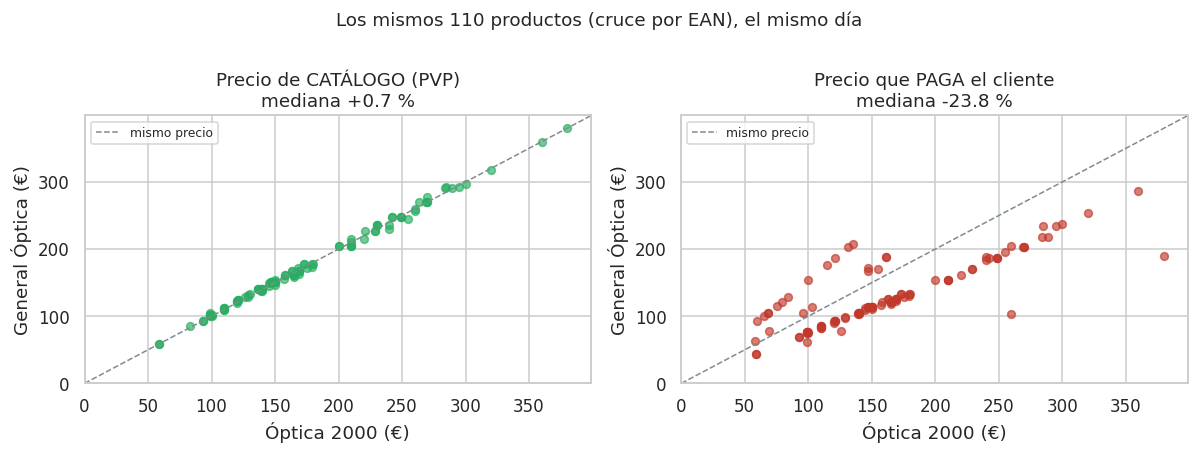

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
lim = [0, max(par["pvp_o2"].max(), par["pvp_go"].max()) * 1.05]
for i, (xo, xg, tit) in enumerate([
        ("pvp_o2", "pvp_go", "Precio de CATÁLOGO (PVP)"),
        ("pagado_o2", "pagado_go", "Precio que PAGA el cliente")]):
    ax[i].plot(lim, lim, "--", color="#7f8c8d", lw=1, label="mismo precio")
    ax[i].scatter(par[xo], par[xg], s=26, alpha=.65, color="#c0392b" if i else "#27ae60")
    ax[i].set_xlim(lim); ax[i].set_ylim(lim)
    ax[i].set_xlabel("Óptica 2000 (€)"); ax[i].set_ylabel("General Óptica (€)")
    ax[i].set_title(f"{tit}\nmediana {par['dif_pvp_%' if i == 0 else 'dif_pagado_%'].median():+.1f} %")
    ax[i].legend(loc="upper left", fontsize=8)
plt.suptitle(f"Los mismos {len(par)} productos (cruce por EAN), el mismo día", y=1.02)
plt.tight_layout(); plt.show()

El precio de catálogo está prácticamente pactado: coincide dentro de un ±5 % en el 99 % de los productos idénticos. Lo que separa a las dos cadenas no es el precio al que dicen vender, sino a quién y cuánto descuentan.

Eso refuerza la decisión de modelar el PVP: es la parte estable y comparable del precio. El precio pagado es política comercial de la semana.

---
## 7. Limitaciones

Declararlas es parte del análisis, no un apéndice.

1. Esto es comercio online, que es en torno al 10 % del mercado español de gafas graduadas. El 85-90 % de las ventas siguen siendo presenciales. Ningún catálogo web es representativo del mercado completo, y este análisis no pretende serlo: describe el surtido y el precio de catálogo de dos cadenas online concretas.
3. Quedan 16 fichas (0,26 %) sin grupo asignado, en 6 marcas menores de General Óptica: Ver Sport, The Wave, XL, Day&Night, Goppies y Lanvin. No se eliminan del dataset a propósito. Borrar filas porque falta una variable cambiaría el denominador del recuento de surtido y descartaría productos válidos para el modelo de precio. Un hueco declarado es preferible a un borrado silencioso. Óptica 2000 está clasificada al 100 %.

   Al clasificar las marcas pequeñas aparecieron dos trampas: "Titan Dynamics Contour" y "Titan Purist" no son de la marca india Titan sino colecciones de titanio de Silhouette; y Hackett no lo licencia ninguno de los cinco grandes grupos sino Mondottica, una licenciataria británica que no estaba en el mapa inicial.
3. Foto de un momento concreto. Los datos se capturaron entre el 2 y el 4 de agosto de 2026. Las campañas promocionales cambian; por eso cada fila lleva su `ts_captura` y por eso el target es el PVP y no el precio del día.
4. El listado de marcas de EssilorLuxottica dice "including": no es exhaustivo. Solo se contó lo demostrable, así que su cuota real podría ser mayor, nunca menor. El error solo puede ir en una dirección, y es la contraria a la que exageraría el hallazgo.
5. Correlación, no causalidad. Se observa que el surtido coincide con la propiedad. No se demuestra que la propiedad *cause* la exclusión: podrían mediar acuerdos de distribución, márgenes o decisiones históricas que estos datos no ven.

### Robustez del hallazgo

Las marcas pequeñas se clasificaron después de calcular el censo, para comprobar si lo cambiaban. Al pasar del 88,2 % al 99,7 % de cobertura en General Óptica:

| | antes | después |
|---|---:|---:|
| General Óptica · De Rigo (su grupo) | 25,6 % | 27,6 % |
| General Óptica · EssilorLuxottica (rival) | 36,5 % | 36,5 % |
| Óptica 2000 · su grupo + marca blanca | 90,2 % | 90,2 % |
| Óptica 2000 · fabricantes rivales | 6,6 % | 6,6 % |

De Rigo sube dos puntos y sigue nueve por debajo de lo que General Óptica dedica a su competidor. El hallazgo no dependía de las marcas sin clasificar.

---
## 8. Conclusiones

1. Se han capturado 6.121 monturas graduadas de las dos cadenas, con precio de catálogo, precio promocional, atributos físicos y EAN, respetando el `robots.txt` de ambas.
2. El surtido está determinado por la propiedad. El 90 % del catálogo de Óptica 2000 pertenece a su dueño o a su marca blanca; los rivales no llegan al 7 %, y cuatro grupos están en cero.
3. La exclusión es unidireccional. General Óptica dedica a EssilorLuxottica el 36,5 % de lo que lista y el 24,5 % de lo que tiene en stock; en los dos casos, muy por encima del 6,6 % que Óptica 2000 dedica a *todos* sus rivales juntos. El grande puede prescindir del pequeño; el pequeño no puede prescindir del grande.
4. Listar y almacenar son decisiones distintas. General Óptica lista mucho producto de Luxottica que no tiene (1.325 de 1.761 agotadas) mientras mantiene disponible más de la mitad de su propio catálogo. El escaparate es de marca ajena; la trastienda, propia.
5. El precio de catálogo está alineado entre cadenas, dentro de ±5 % en el 99 % de los productos idénticos, pero el precio pagado difiere un 24 %. La competencia entre estas dos cadenas no ocurre en el precio nominal sino en la política de descuento.

Siguiente paso: modelar el PVP a partir de atributos físicos, marca, grupo propietario y tienda, para separar cuánto del precio explica el producto y cuánto el posicionamiento de marca.